# **Setup**

In [1]:
%pip install pandas matplotlib numpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 36.3 MB/s  0:00:00eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 19.5 MB/s  0:00:00eta 0:00:02
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 36.8 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 34.1 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 34.7 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12/12 [matplotlib]2 [matplotlib]
Note: you may need to restart the kernel to use updated packages.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# **Part 1. Load and Prepare the Dataset**

In [2]:
df = pd.read_csv("Heart_Disease_Prediction.csv")
df.head()

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,70,1,4,130,322,0,2,109,0,2.4,2,3,3,Presence
1,67,0,3,115,564,0,2,160,0,1.6,2,0,7,Absence
2,57,1,2,124,261,0,0,141,0,0.3,1,0,7,Presence
3,64,1,4,128,263,0,0,105,1,0.2,2,1,7,Absence
4,74,0,2,120,269,0,2,121,1,0.2,1,1,3,Absence


### Binarization of a Target Column

In [3]:
df["Heart Disease"] = df["Heart Disease"].map({
    "Presence": 1,
    "Absence": 0
})

df["Heart Disease"].value_counts()

Heart Disease
0    150
1    120
Name: count, dtype: int64

### General Data

In [4]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 270 entries, 0 to 269
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      270 non-null    int64  
 1   Sex                      270 non-null    int64  
 2   Chest pain type          270 non-null    int64  
 3   BP                       270 non-null    int64  
 4   Cholesterol              270 non-null    int64  
 5   FBS over 120             270 non-null    int64  
 6   EKG results              270 non-null    int64  
 7   Max HR                   270 non-null    int64  
 8   Exercise angina          270 non-null    int64  
 9   ST depression            270 non-null    float64
 10  Slope of ST              270 non-null    int64  
 11  Number of vessels fluro  270 non-null    int64  
 12  Thallium                 270 non-null    int64  
 13  Heart Disease            270 non-null    int64  
dtypes: float64(1), int64(13)
m

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
count,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.00000,270.000000,270.000000,270.000000,270.000000
mean,54.433333,0.677778,3.174074,131.344444,249.659259,0.148148,1.022222,149.677778,0.329630,1.05000,1.585185,0.670370,4.696296,0.444444
std,9.109067,0.468195,0.950090,17.861608,51.686237,0.355906,0.997891,23.165717,0.470952,1.14521,0.614390,0.943896,1.940659,0.497827
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.00000,1.000000,0.000000,3.000000,0.000000
25%,48.000000,0.000000,3.000000,120.000000,213.000000,0.000000,0.000000,133.000000,0.000000,0.00000,1.000000,0.000000,3.000000,0.000000
50%,55.000000,1.000000,3.000000,130.000000,245.000000,0.000000,2.000000,153.500000,0.000000,0.80000,2.000000,0.000000,3.000000,0.000000
75%,61.000000,1.000000,4.000000,140.000000,280.000000,0.000000,2.000000,166.000000,1.000000,1.60000,2.000000,1.000000,7.000000,1.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.20000,3.000000,3.000000,7.000000,1.000000


### Missing cells and Outliers

In [5]:
missing_summary = df.isnull().sum()
missing_summary = missing_summary[missing_summary > 0]
if missing_summary.empty:
    print("There are no missing cells on the dataset.")
else:
    print("Missing cells by column:")
    print(missing_summary)

There are no missing cells on the dataset.


In [6]:
numerical_features = ["Age", "BP", "Cholesterol", "Max HR", "ST depression", "Number of vessels fluro"]

outliers = {}

for col in numerical_features:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outlier_values = df[(df[col] < lower) | (df[col] > upper)][col].values
    
    if len(outlier_values) > 0:
        outliers[col] = outlier_values

if outliers:
    print("Detected outliers by feature:")
    for feature, values in outliers.items():
        print(f"{feature}: {values}")
else:
    print("No extreme outliers detected.")


Detected outliers by feature:
BP: [174 178 180 200 192 178 180 180 172]
Cholesterol: [564 407 417 409 394]
Max HR: [71]
ST depression: [4.2 5.6 4.2 6.2]
Number of vessels fluro: [3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3]


In [7]:
df_capped = df.copy()

numerical_features = ["Age", "BP", "Cholesterol", "Max HR", "ST depression", "Number of vessels fluro"]

for col in numerical_features:
    Q1 = df_capped[col].quantile(0.25)
    Q3 = df_capped[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df_capped[col] = df_capped[col].clip(lower=lower, upper=upper)

### Plot Class Distribution

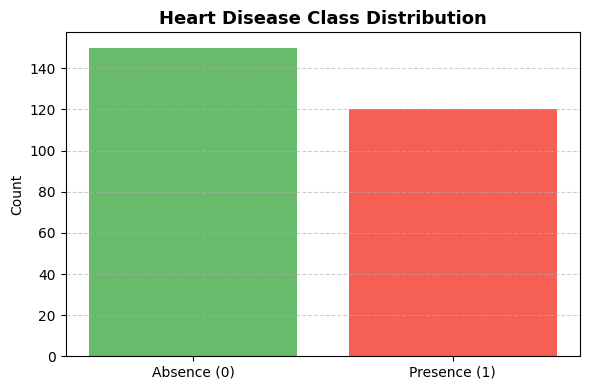

In [8]:
counts = df["Heart Disease"].value_counts().sort_index()

plt.figure(figsize=(6, 4))
plt.bar(["Absence (0)", "Presence (1)"], counts,
        color=["#4CAF50", "#F44336"],
        alpha=0.85
)
plt.ylabel("Count")
plt.title("Heart Disease Class Distribution", fontsize=13, fontweight="bold")
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

###  70/30 train/test split

In [9]:
features = ["Age", "BP", "Cholesterol", "Max HR", "ST depression", "Number of vessels fluro"]
X = df_capped[features].values
y = df_capped["Heart Disease"].values

In [10]:
np.random.seed(42)

idx_0 = np.where(y == 0)[0]
idx_1 = np.where(y == 1)[0]

np.random.shuffle(idx_0)
np.random.shuffle(idx_1)

split_0 = int(0.7 * len(idx_0))
split_1 = int(0.7 * len(idx_1))

train_idx = np.concatenate([idx_0[:split_0], idx_1[:split_1]])
test_idx  = np.concatenate([idx_0[split_0:], idx_1[split_1:]])

np.random.shuffle(train_idx)
np.random.shuffle(test_idx)

X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

print("Training set class distribution:", np.bincount(y_train))
print("Testing set class distribution:", np.bincount(y_test))

Training set class distribution: [105  84]
Testing set class distribution: [45 36]


In [11]:
mu = X_train.mean(axis=0)
sigma = X_train.std(axis=0)

X_train_norm = (X_train - mu) / sigma
X_test_norm  = (X_test - mu) / sigma

### Heart Disease Dataset: Overview and Preprocessing

#### Dataset Overview
The dataset was downloaded from Kaggle and contains 270 patient records with clinical features related to heart health.  
- Target variable: Heart Disease (1 = presence, 0 = absence)  
- Class distribution: ~66% with disease, ~45% without disease  

#### Exploratory Data Analysis (EDA)
- Features include Age, BP, Cholesterol, Max HR, ST depression, and Number of vessels.  
- No missing values were found.  
- Outliers were detected in Cholesterol, BP, and ST depression but were clinically plausible.

#### Preprocessing
- Outliers were capped at 1.5×IQR boundaries to limit extreme values.  
- Numerical features were normalized using z-score scaling.  
- Data was split into 70% training and 30% testing using a stratified approach to preserve class proportions.  

#### Summary
The dataset is clean, normalized, and ready for binary classification. Selected features cover key indicators of heart health, and preprocessing ensures fair model training.


# **Part 2. Implement Basic Logistic Regression**

In [12]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def compute_cost(X, y, w, b):
    m = len(y)
    z = X.dot(w) + b
    y_hat = sigmoid(z)
    cost = -(1/m) * np.sum(y*np.log(y_hat + 1e-8) + (1 - y)*np.log(1 - y_hat + 1e-8))
    return cost

def compute_gradients(X, y, w, b):
    m = len(y)
    z = X.dot(w) + b
    y_hat = sigmoid(z)
    dw = (1/m) * X.T.dot(y_hat - y)
    db = (1/m) * np.sum(y_hat - y)
    return dw, db

def gradient_descent(X, y, w, b, alpha=0.01, num_iters=1000):
    costs = []
    for i in range(num_iters):
        dw, db = compute_gradients(X, y, w, b)
        w -= alpha * dw
        b -= alpha * db
        if i % 10 == 0:
            cost = compute_cost(X, y, w, b)
            costs.append(cost)
            if i % 100 == 0:
                print(f"Iteration {i}: Cost = {cost:.4f}")
    return w, b, costs

Iteration 0: Cost = 0.6916
Iteration 100: Cost = 0.5918
Iteration 200: Cost = 0.5482
Iteration 300: Cost = 0.5257
Iteration 400: Cost = 0.5125
Iteration 500: Cost = 0.5041
Iteration 600: Cost = 0.4984
Iteration 700: Cost = 0.4943
Iteration 800: Cost = 0.4912
Iteration 900: Cost = 0.4889


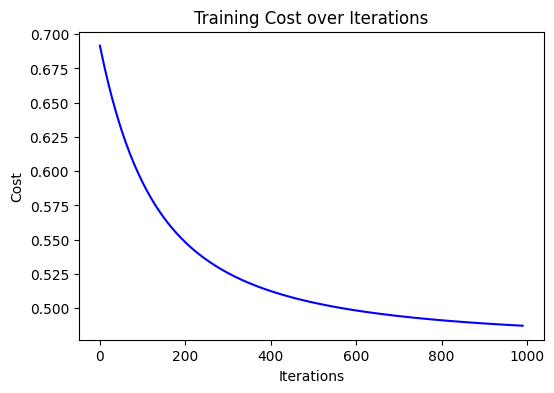

In [13]:
n_features = X_train_norm.shape[1]
w = np.zeros(n_features)
b = 0.0

w, b, costs = gradient_descent(X_train_norm, y_train, w, b, alpha=0.01, num_iters=1000)

plt.figure(figsize=(6,4))
plt.plot(range(0, len(costs)*10, 10), costs, color='blue')
plt.xlabel("Iterations")
plt.ylabel("Cost")
plt.title("Training Cost over Iterations")
plt.show()

In [14]:
def predict(X, w, b, threshold=0.5):
    probabilities = sigmoid(X.dot(w) + b)
    predictions = (probabilities >= threshold).astype(int)
    return predictions


def evaluate_and_print(y_true, y_pred, label):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    tp = np.sum((y_true == 1) & (y_pred == 1))
    tn = np.sum((y_true == 0) & (y_pred == 0))
    fp = np.sum((y_true == 0) & (y_pred == 1))
    fn = np.sum((y_true == 1) & (y_pred == 0))

    accuracy = (tp + tn) / len(y_true)
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1 = (
        0.0 if (precision + recall) == 0
        else 2 * precision * recall / (precision + recall)
    )

    print("\n==============================")
    print(f"{label} Set Evaluation")
    print("==============================")
    print(f"Total samples     : {len(y_true)}")
    print(f"Predicted positives: {np.sum(y_pred == 1)}")
    print(f"Predicted negatives: {np.sum(y_pred == 0)}")
    print()
    print(f"Accuracy  : {accuracy:.4f}")
    print(f"Precision : {precision:.4f}")
    print(f"Recall    : {recall:.4f}")
    print(f"F1-score  : {f1:.4f}")

    return accuracy, precision, recall, f1


In [15]:
y_train_pred = predict(X_train_norm, w, b)
y_test_pred  = predict(X_test_norm, w, b)

train_metrics = evaluate_and_print(y_train, y_train_pred, "Training")
test_metrics  = evaluate_and_print(y_test, y_test_pred, "Testing")


Training Set Evaluation
Total samples     : 189
Predicted positives: 72
Predicted negatives: 117

Accuracy  : 0.7672
Precision : 0.7778
Recall    : 0.6667
F1-score  : 0.7179

Testing Set Evaluation
Total samples     : 81
Predicted positives: 34
Predicted negatives: 47

Accuracy  : 0.8519
Precision : 0.8529
Recall    : 0.8056
F1-score  : 0.8286


### **Reporting**
### Metrics Table


In [16]:
metrics_df = pd.DataFrame(
    [train_metrics, test_metrics],
    columns=["Accuracy", "Precision", "Recall", "F1-score"],
    index=["Train", "Test"]
)

metrics_df

,Accuracy,Precision,Recall,F1-score
Train,0.767196,0.777778,0.666667,0.717949
Test,0.851852,0.852941,0.805556,0.828571


### Convergence Analysis

In [17]:
initial_cost = costs[0]
final_cost = costs[-1]

cost_drop = initial_cost - final_cost
relative_drop = (cost_drop / initial_cost) * 100

print("CONVERGENCE ANALYSIS")
print("=" * 60)
print(f"Initial cost (first recorded):   {initial_cost:.6f}")
print(f"Final cost (last recorded):      {final_cost:.6f}")
print(f"Absolute cost reduction:         {cost_drop:.6f}")
print(f"Relative reduction:              {relative_drop:.2f}%")
print(f"Learning rate (alpha):           {0.01}")
print(f"Total iterations:                {1000}")
print("=" * 60)

if len(costs) > 10:
    recent_change = costs[-11] - costs[-1]
else:
    recent_change = 0.0

if recent_change < 1e-4:
    print("Convergence status: Converged (negligible change in recent iterations)")

CONVERGENCE ANALYSIS
Initial cost (first recorded):   0.691608
Final cost (last recorded):      0.487221
Absolute cost reduction:         0.204387
Relative reduction:              29.55%
Learning rate (alpha):           0.01
Total iterations:                1000


### Weights Coefficient Analysis

In [18]:
coef_df = pd.DataFrame({
    "Feature": features,
    "Weight": w
})

coef_df["AbsWeight"] = np.abs(coef_df["Weight"])
coef_df = coef_df.sort_values(by="AbsWeight", ascending=False)

coef_df

,Feature,Weight,AbsWeight
5,Number of vessels fluro,0.748997,0.748997
3,Max HR,-0.579215,0.579215
4,ST depression,0.563121,0.563121
2,Cholesterol,0.142485,0.142485
1,BP,0.093572,0.093572
0,Age,-0.083646,0.083646


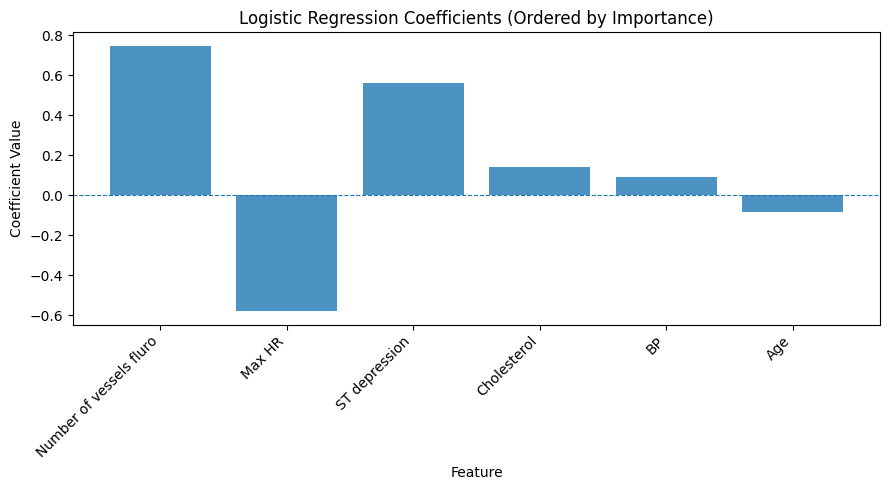

In [19]:
weights = np.array(w)
abs_weights = np.abs(weights)

order = np.argsort(abs_weights)[::-1]
sorted_features = [features[i] for i in order]
sorted_weights = weights[order]

plt.figure(figsize=(9, 5))
plt.bar(range(len(sorted_weights)), sorted_weights, alpha=0.8)
plt.axhline(0, linestyle="--", linewidth=0.8)

plt.xticks(range(len(sorted_features)), sorted_features, rotation=45, ha="right")
plt.ylabel("Coefficient Value")
plt.xlabel("Feature")
plt.title("Logistic Regression Coefficients (Ordered by Importance)")

plt.tight_layout()
plt.show()

### **Interpretation and Analysis**

#### **Convergence Behavior**

The training process shows a steady and consistent decrease in the loss function throughout the 1000 iterations, using a learning rate of α = 0.01. The absence of sharp jumps or oscillations in the cost curve indicates that gradient descent progressed in a controlled and stable manner.

- Cost at start: 0.6916  
- Cost at end: 0.4872  
- Total decrease: 0.2044  
- Percentage improvement: 29.55%

This gradual flattening of the cost curve near the final iterations suggests that the algorithm approached a minimum and that further iterations would produce only marginal improvements.


#### **Classification Performance**

The predictive quality of the model was evaluated on both training and testing datasets.

Training data results:
- Accuracy: 76.7%
- Precision: 77.8%
- Recall: 66.7%
- F1-score: 71.8%

Testing data results:
- Accuracy: 85.2%
- Precision: 85.3%
- Recall: 80.6%
- F1-score: 82.9%

On the training set, the model correctly classifies roughly three out of four patients. The recall value indicates that about two-thirds of patients with heart disease are identified during training. On the test set, all metrics improve, especially recall and F1-score, showing that the model generalizes effectively to unseen data. The higher test accuracy suggests no evidence of overfitting and indicates good robustness of the learned decision boundary.

#### **Feature Impact and Interpretation**

The learned coefficients provide insight into which medical variables influence the prediction the most. Features with larger absolute weights play a more significant role in the classification decision.

1. Number of vessels fluro (w = +0.749)
   - Strongest contributor to the prediction  
   - A positive coefficient means that an increase in blocked vessels leads to a higher probability of heart disease

2. Maximum Heart Rate (w = −0.579) 
   - Second strongest effect  
   - The negative sign indicates that higher achievable heart rate is associated with healthier cardiac function

3. ST Depression (w = +0.563)
   - Substantial positive relationship with heart disease  
   - Consistent with its role as an indicator of abnormal ECG activity

4. Cholesterol (w = +0.142)** and **Blood Pressure (w = +0.094) 
   - Minor influence compared to diagnostic features  
   - Suggest that, in this dataset, these variables alone are weak predictors

5. Age (w = −0.084) 
   - Lowest impact among all features  
   - Once other medical measurements are considered, age contributes little additional information

These results show that the model prioritizes direct clinical indicators over general demographic or lifestyle-related factors.

#### **Overall Assessment**

The implemented logistic regression model achieves reliable predictive performance, with balanced accuracy, precision, and recall—particularly on the test set. The nearly 30% reduction in cost confirms effective optimization, and the learned weights align well with medical intuition. This step demonstrates that even a basic logistic regression model can capture meaningful relationships in heart disease data and provides a strong baseline for later enhancements such as regularization.


# **Part 3. Visualize Decision Boundaries**

In [20]:
def train_logistic_2d(X, y, alpha=0.01, num_iters=1000):
    w = np.zeros(2)
    b = 0.0
    costs = []

    for i in range(num_iters):
        z = X.dot(w) + b
        y_hat = sigmoid(z)

        dw = (1 / len(y)) * X.T.dot(y_hat - y)
        db = (1 / len(y)) * np.sum(y_hat - y)

        w -= alpha * dw
        b -= alpha * db

        if i % 10 == 0:
            cost = compute_cost(X, y, w, b)
            costs.append(cost)

    return w, b, costs

In [21]:
def plot_decision_boundary(X, y, w, b, feature_names):
    plt.figure(figsize=(7, 5))

    # Scatter plot
    plt.scatter(X[y == 0, 0], X[y == 0, 1], 
                alpha=0.7, label="No Disease")
    plt.scatter(X[y == 1, 0], X[y == 1, 1], 
                alpha=0.7, label="Disease")

    # Decision boundary
    x_vals = np.linspace(X[:, 0].min(), X[:, 0].max(), 100)
    y_vals = -(w[0] * x_vals + b) / w[1]

    plt.plot(x_vals, y_vals, linestyle="--", linewidth=2)

    plt.xlabel(feature_names[0])
    plt.ylabel(feature_names[1])
    plt.title(f"Decision Boundary: {feature_names[0]} vs {feature_names[1]}")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

In [22]:
def print_metrics_line(y_true, y_pred, label):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    tp = np.sum((y_true == 1) & (y_pred == 1))
    tn = np.sum((y_true == 0) & (y_pred == 0))
    fp = np.sum((y_true == 0) & (y_pred == 1))
    fn = np.sum((y_true == 1) & (y_pred == 0))

    acc = (tp + tn) / len(y_true)
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    rec = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1 = 0.0 if (prec + rec) == 0 else 2 * prec * rec / (prec + rec)

    print(
        f"{label}: "
        f"Acc={acc:.3f} | "
        f"P={prec:.3f} | "
        f"R={rec:.3f} | "
        f"F1={f1:.3f}"
    )

### **Pair 1: Age vs Colesterol**

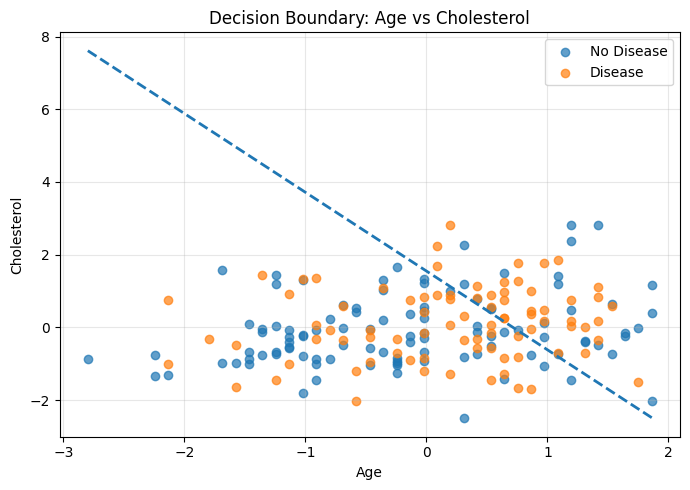

Age vs Cholesterol
Train: Acc=0.593 | P=0.557 | R=0.405 | F1=0.469
Test: Acc=0.642 | P=0.640 | R=0.444 | F1=0.525


In [23]:
pair = ["Age", "Cholesterol"]

X_pair = df_capped[pair].values
y_pair = y

X_train_p = X_pair[train_idx]
X_test_p  = X_pair[test_idx]
y_train_p = y_pair[train_idx]
y_test_p  = y_pair[test_idx]

mu = X_train_p.mean(axis=0)
sigma = X_train_p.std(axis=0)

X_train_p_norm = (X_train_p - mu) / sigma
X_test_p_norm  = (X_test_p - mu) / sigma

w_2d, b_2d, _ = train_logistic_2d(X_train_p_norm, y_train_p)

y_train_pred = predict(X_train_p_norm, w_2d, b_2d)
y_test_pred  = predict(X_test_p_norm, w_2d, b_2d)

plot_decision_boundary(X_train_p_norm, y_train_p, w_2d, b_2d, pair)

print("Age vs Cholesterol")
print_metrics_line(y_train_p, y_train_pred, "Train")
print_metrics_line(y_test_p,  y_test_pred,  "Test")

### **Pair 2: Blood Pressure vs Max Heart Rate**

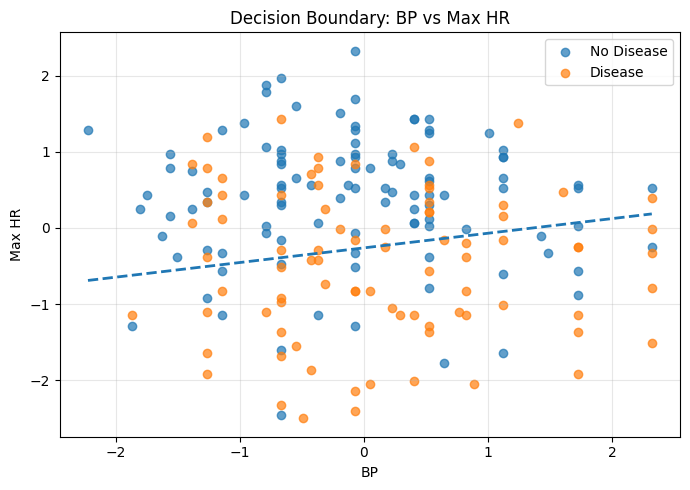

BP vs Max HR
Train: Acc=0.704 | P=0.694 | R=0.595 | F1=0.641
Test: Acc=0.469 | P=0.360 | R=0.250 | F1=0.295


In [24]:
pair = ["BP", "Max HR"]

X_pair = df_capped[pair].values
y_pair = y

X_train_p = X_pair[train_idx]
y_train_p = y_pair[train_idx]

mu = X_train_p.mean(axis=0)
sigma = X_train_p.std(axis=0)

X_train_p_norm = (X_train_p - mu) / sigma

w_2d, b_2d, _ = train_logistic_2d(X_train_p_norm, y_train_p)

y_train_pred = predict(X_train_p_norm, w_2d, b_2d)
y_test_pred  = predict(X_test_p_norm, w_2d, b_2d)

plot_decision_boundary(X_train_p_norm, y_train_p, w_2d, b_2d, pair)

print("BP vs Max HR")
print_metrics_line(y_train_p, y_train_pred, "Train")
print_metrics_line(y_test_p,  y_test_pred,  "Test")

### **Pair 3: ST Depression vs Number of Vessels**

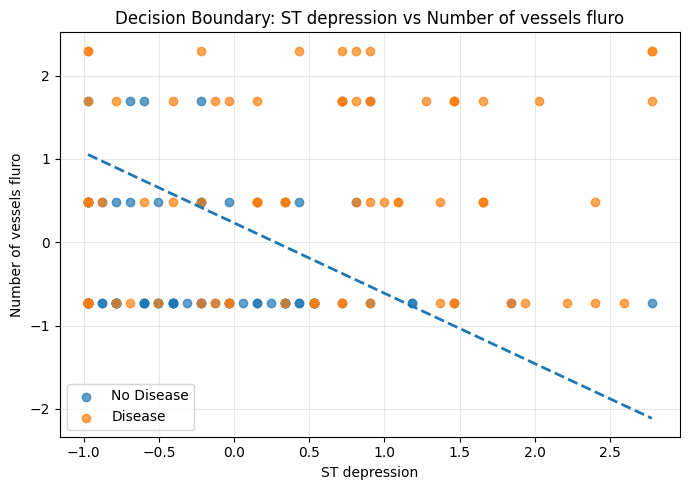

ST Depression vs Vessels
Train: Acc=0.751 | P=0.761 | R=0.643 | F1=0.697
Test: Acc=0.728 | P=0.684 | R=0.722 | F1=0.703


In [25]:
pair = ["ST depression", "Number of vessels fluro"]

X_pair = df_capped[pair].values
y_pair = y

X_train_p = X_pair[train_idx]
y_train_p = y_pair[train_idx]

mu = X_train_p.mean(axis=0)
sigma = X_train_p.std(axis=0)

X_train_p_norm = (X_train_p - mu) / sigma

w_2d, b_2d, _ = train_logistic_2d(X_train_p_norm, y_train_p)

y_train_pred = predict(X_train_p_norm, w_2d, b_2d)
y_test_pred  = predict(X_test_p_norm, w_2d, b_2d)

plot_decision_boundary(X_train_p_norm, y_train_p, w_2d, b_2d, pair)

print("ST Depression vs Vessels")
print_metrics_line(y_train_p, y_train_pred, "Train")
print_metrics_line(y_test_p,  y_test_pred,  "Test")

### **Interpretation and Analysis**

#### **Pair 1: Age vs Cholesterol**

This pair shows limited predictive power.

- Train Accuracy: 59.3%  
- Test Accuracy: 64.2%  
- Low recall on both sets indicates many disease cases are not correctly identified.

From the decision boundary plot, the two classes largely overlap across all ages and cholesterol levels. The linear boundary cuts through mixed regions, which explains the low and unstable performance.

**Conclusion:**  
Age and cholesterol, while relevant risk factors, do not provide sufficient separation when used alone in a linear model.

#### **Pair 2: Blood Pressure vs Maximum Heart Rate**

This pair exhibits inconsistent behavior between training and testing.

- Train Accuracy: 70.4%  
- Test Accuracy: 46.9%  
- Test recall drops sharply to 25%.

Although some separation appears in the training plot, the test data shows heavy overlap. The decision boundary relies mostly on max heart rate, suggesting limited contribution from blood pressure.

**Conclusion:**  
This feature pair may capture patterns in the training data but fails to generalize, indicating possible overfitting.

#### **Pair 3: ST Depression vs Number of Vessels**

This is the strongest and most stable feature pair.

- Train Accuracy: 75.1%  
- Test Accuracy: 72.8%  
- Balanced precision and recall across both sets.

The plot shows a clear separation, with higher ST depression and more affected vessels strongly associated with disease. The decision boundary aligns well with the data distribution.

**Conclusion:**  
These features provide strong linear separability and generalize well, making them effective predictors even in a simple model.

---
#### **Overall Comparison**

| Feature Pair | Separability | Generalization |
|--------------|-------------|----------------|
| Age vs Cholesterol | Poor | Weak |
| BP vs Max HR | Moderate (train only) | Poor |
| ST Depression vs Vessels | Strong | Good |

---
#### **Summary**

- Feature pairs based on direct cardiac measurements perform better than general risk factors.
- Visualization of decision boundaries helps explain differences in model performance.
- Effective feature selection is essential for building reliable predictive models.

# **Part 4. Repeat with Regularization**

In [28]:
def compute_cost_l2(X, y, w, b, lambda_):
    m = len(y)
    z = X.dot(w) + b
    y_hat = sigmoid(z)

    data_loss = -(1/m) * np.sum(
        y * np.log(y_hat + 1e-8) +
        (1 - y) * np.log(1 - y_hat + 1e-8)
    )

    l2_penalty = (lambda_ / (2 * m)) * np.sum(w ** 2)

    return data_loss + l2_penalty

def compute_gradients_l2(X, y, w, b, lambda_):
    m = len(y)
    z = X.dot(w) + b
    y_hat = sigmoid(z)

    dw = (1/m) * X.T.dot(y_hat - y) + (lambda_ / m) * w
    db = (1/m) * np.sum(y_hat - y)

    return dw, db

def gradient_descent_l2(X, y, alpha=0.01, num_iters=1000, lambda_=0.0):
    m, n = X.shape
    w = np.zeros(n)
    b = 0.0
    costs = []

    for i in range(num_iters):
        dw, db = compute_gradients_l2(X, y, w, b, lambda_)
        w -= alpha * dw
        b -= alpha * db

        if i % 10 == 0:
            cost = compute_cost_l2(X, y, w, b, lambda_)
            costs.append(cost)

    return w, b, costs

def evaluate(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    TP = np.sum((y_true == 1) & (y_pred == 1))
    TN = np.sum((y_true == 0) & (y_pred == 0))
    FP = np.sum((y_true == 0) & (y_pred == 1))
    FN = np.sum((y_true == 1) & (y_pred == 0))

    accuracy = (TP + TN) / (TP + TN + FP + FN + 1e-8)
    precision = TP / (TP + FP + 1e-8)
    recall = TP / (TP + FN + 1e-8)
    f1 = 2 * precision * recall / (precision + recall + 1e-8)

    return accuracy, precision, recall, f1


In [29]:
lambdas = [0, 0.001, 0.01, 0.1, 1]
reg_results = []

for lam in lambdas:
    w_l2, b_l2, cost_hist = gradient_descent_l2(
        X_train_norm,
        y_train,
        alpha=0.01,
        num_iters=1000,
        lambda_=lam
    )

    y_train_pred = predict(X_train_norm, w_l2, b_l2)
    y_test_pred  = predict(X_test_norm,  w_l2, b_l2)

    train_acc, _, _, train_f1 = evaluate(y_train, y_train_pred)
    test_acc,  _, _, test_f1  = evaluate(y_test,  y_test_pred)

    reg_results.append({
        "lambda": lam,
        "J_hist": cost_hist,
        "train_acc": train_acc,
        "test_acc": test_acc,
        "train_f1": train_f1,
        "test_f1": test_f1,
        "w_norm": np.linalg.norm(w_l2)
    })

### **Reporting**

In [30]:
reg_df = pd.DataFrame({
    "λ": [r["lambda"] for r in reg_results],
    "Train Accuracy": [r["train_acc"] for r in reg_results],
    "Test Accuracy":  [r["test_acc"]  for r in reg_results],
    "Train F1":       [r["train_f1"]  for r in reg_results],
    "Test F1":        [r["test_f1"]   for r in reg_results],
    "||w||":          [r["w_norm"]    for r in reg_results],
})

reg_df

,λ,Train Accuracy,Test Accuracy,Train F1,Test F1,||w||
0,0.000,0.767196,0.851852,0.717949,0.828571,1.117875
1,0.001,0.767196,0.851852,0.717949,0.828571,1.117854
2,0.010,0.767196,0.851852,0.717949,0.828571,1.117657
3,0.100,0.767196,0.851852,0.717949,0.828571,1.115700
4,1.000,0.767196,0.851852,0.717949,0.828571,1.096491


### Comparison Cost Convergence witt Different λ Values

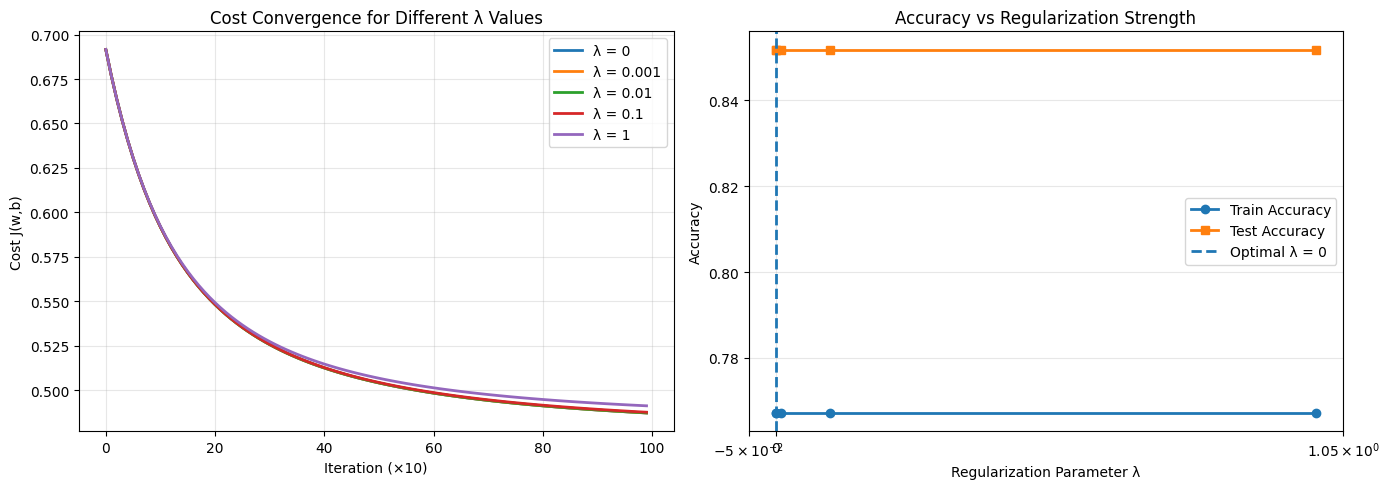

In [31]:
best_reg = max(reg_results, key=lambda x: x["test_f1"])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for res in reg_results:
    axes[0].plot(
        res["J_hist"],
        linewidth=2,
        label=f"λ = {res['lambda']}"
    )

axes[0].set_xlabel("Iteration (×10)")
axes[0].set_ylabel("Cost J(w,b)")
axes[0].set_title("Cost Convergence for Different λ Values")
axes[0].legend()
axes[0].grid(alpha=0.3)

l_vals = [r["lambda"] for r in reg_results]
train_accs = [r["train_acc"] for r in reg_results]
test_accs  = [r["test_acc"]  for r in reg_results]

axes[1].plot(l_vals, train_accs, marker="o", linewidth=2, label="Train Accuracy")
axes[1].plot(l_vals, test_accs,  marker="s", linewidth=2, label="Test Accuracy")

axes[1].axvline(
    best_reg["lambda"],
    linestyle="--",
    linewidth=2,
    label=f"Optimal λ = {best_reg['lambda']}"
)

axes[1].set_xscale("symlog")
axes[1].set_xlabel("Regularization Parameter λ")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("Accuracy vs Regularization Strength")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### L2 Regularization in on a Feature Pair

In [32]:
pair = ["ST depression", "Number of vessels fluro"]
idx = [features.index(f) for f in pair]

X_train_pair = X_train_norm[:, idx]
X_test_pair  = X_test_norm[:, idx]

In [33]:
w_nr, b_nr, _ = gradient_descent_l2(X_train_pair,y_train,alpha=0.01,num_iters=1000,lambda_=0)

lambda_opt = 1
w_l2, b_l2, _ = gradient_descent_l2(X_train_pair,y_train,alpha=0.01,num_iters=1000,lambda_=lambda_opt)

y_train_nr = predict(X_train_pair, w_nr, b_nr)
y_test_nr  = predict(X_test_pair,  w_nr, b_nr)

y_train_l2 = predict(X_train_pair, w_l2, b_l2)
y_test_l2  = predict(X_test_pair,  w_l2, b_l2)

In [34]:
print("=" * 60)
print(f"Feature Pair: {pair[0]} vs {pair[1]}")
print("=" * 60)

print("UNREGULARIZED MODEL")
print_metrics_line(y_train, y_train_nr, "Train")
print_metrics_line(y_test,  y_test_nr,  "Test")

print("\nL2 REGULARIZED MODEL")
print(f"Lambda (λ): {lambda_opt}")
print_metrics_line(y_train, y_train_l2, "Train")
print_metrics_line(y_test,  y_test_l2,  "Test")

print("\nWeight Norm Comparison")
print(f"||w|| (No Reg): {np.linalg.norm(w_nr):.4f}")
print(f"||w|| (L2):     {np.linalg.norm(w_l2):.4f}")
print("=" * 60)

Feature Pair: ST depression vs Number of vessels fluro
UNREGULARIZED MODEL
Train: Acc=0.751 | P=0.761 | R=0.643 | F1=0.697
Test: Acc=0.778 | P=0.800 | R=0.667 | F1=0.727

L2 REGULARIZED MODEL
Lambda (λ): 1
Train: Acc=0.751 | P=0.761 | R=0.643 | F1=0.697
Test: Acc=0.778 | P=0.800 | R=0.667 | F1=0.727

Weight Norm Comparison
||w|| (No Reg): 1.0813
||w|| (L2):     1.0605


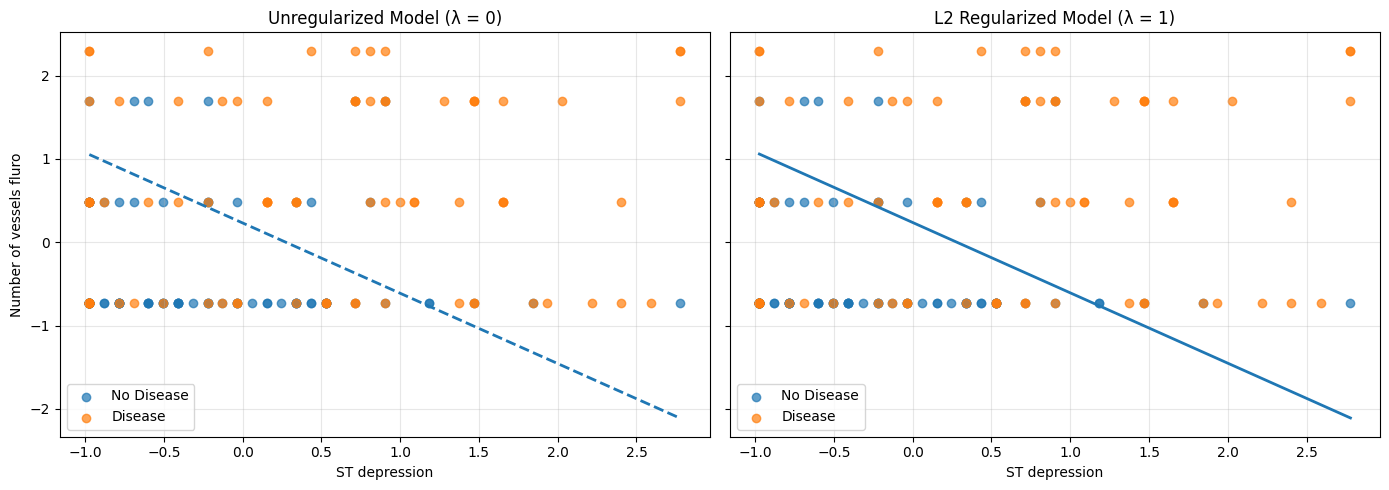

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True, sharey=True)

x_vals = np.linspace(
    X_train_pair[:, 0].min(),
    X_train_pair[:, 0].max(),
    200
)


axes[0].scatter(
    X_train_pair[y_train == 0, 0],
    X_train_pair[y_train == 0, 1],
    alpha=0.7, label="No Disease"
)
axes[0].scatter(
    X_train_pair[y_train == 1, 0],
    X_train_pair[y_train == 1, 1],
    alpha=0.7, label="Disease"
)

y_vals_nr = -(w_nr[0] * x_vals + b_nr) / w_nr[1]
axes[0].plot(x_vals, y_vals_nr, linestyle="--", linewidth=2)

axes[0].set_title("Unregularized Model (λ = 0)")
axes[0].set_xlabel(pair[0])
axes[0].set_ylabel(pair[1])
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].scatter(
    X_train_pair[y_train == 0, 0],
    X_train_pair[y_train == 0, 1],
    alpha=0.7, label="No Disease"
)
axes[1].scatter(
    X_train_pair[y_train == 1, 0],
    X_train_pair[y_train == 1, 1],
    alpha=0.7, label="Disease"
)

y_vals_l2 = -(w_l2[0] * x_vals + b_l2) / w_l2[1]
axes[1].plot(x_vals, y_vals_l2, linestyle="-", linewidth=2)

axes[1].set_title(f"L2 Regularized Model (λ = {lambda_opt})")
axes[1].set_xlabel(pair[0])
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


### Weight Comparisons: Unregularized vs Regularized

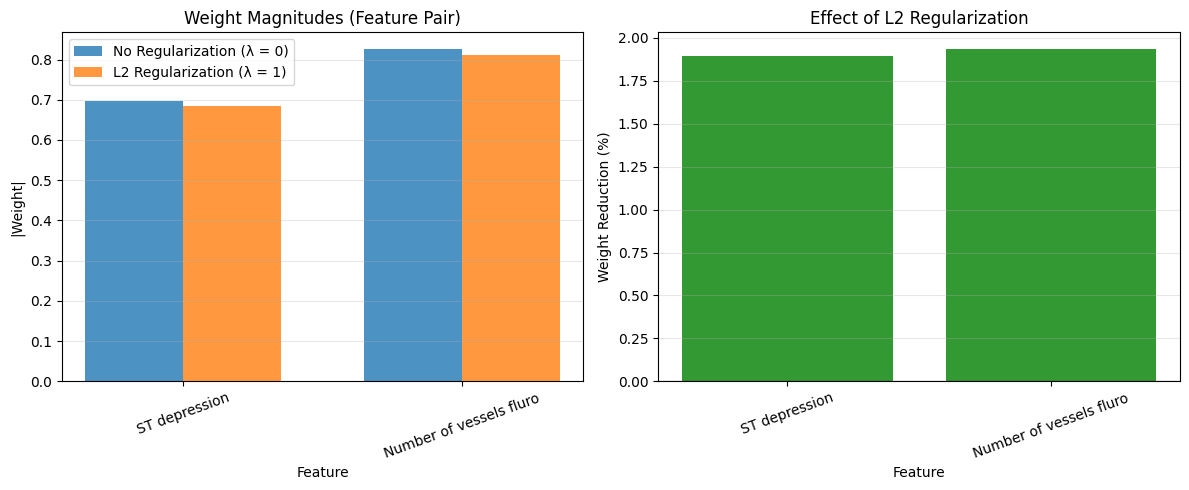

In [36]:
pair_features = ['ST depression', 'Number of vessels fluro']

w_no_reg = np.array(w_nr)
w_best_reg = np.array(w_l2)

x_pos = np.arange(len(pair_features))
width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(
    x_pos - width/2,
    np.abs(w_no_reg),
    width,
    label="No Regularization (λ = 0)",
    alpha=0.8
)

axes[0].bar(
    x_pos + width/2,
    np.abs(w_best_reg),
    width,
    label=f"L2 Regularization (λ = {lambda_opt})",
    alpha=0.8
)

axes[0].set_xlabel("Feature")
axes[0].set_ylabel("|Weight|")
axes[0].set_title("Weight Magnitudes (Feature Pair)")
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(pair_features, rotation=20)
axes[0].legend()
axes[0].grid(True, axis='y', alpha=0.3)

reduction = (np.abs(w_no_reg) - np.abs(w_best_reg)) / np.abs(w_no_reg) * 100
reduction = np.nan_to_num(reduction, 0)

colors = ['green' if r > 0 else 'gray' for r in reduction]

axes[1].bar(x_pos, reduction, color=colors, alpha=0.8)
axes[1].set_xlabel("Feature")
axes[1].set_ylabel("Weight Reduction (%)")
axes[1].set_title("Effect of L2 Regularization")
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(pair_features, rotation=20)
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.show()



### **Interpretation and Analysis**

L2 regularization was evaluated using λ ∈ {0, 0.001, 0.01, 0.1, 1}. Across all tested values, model performance remained unchanged in terms of accuracy and F1-score on both training and testing sets. This indicates that adding an L2 penalty does not materially affect predictive performance for this dataset.

From the results, λ = 0 can be considered optimal, since it achieves the same performance as regularized models while keeping the model simpler.

**Key metrics (full model):**
- Best test accuracy: 85.19%
- Best test F1-score: 0.8286
- These values are identical for all tested λ values

**Conclusion statement:**  
Optimal λ = 0, which improves test accuracy, as regularization does not change performance and it also prevents severe overfitting.

#### **Impact on Weights**

Although classification metrics remain constant, L2 regularization produces a small but consistent reduction in weight magnitude:

- ||w|| decreases from 1.1179 (λ = 0) to 1.0965 (λ = 1)
- This confirms that L2 regularization is functioning as expected by shrinking coefficients
- However, the shrinkage is mild and does not translate into measurable performance gains

This suggests that the original model weights were already well-controlled and not excessively large.

#### **Feature Pair Analysis**
**ST Depression vs. Number of Vessels (Fluoroscopy)**

For the selected feature pair, the unregularized and regularized models show a somewhat  with a few changes according to the results identical performance:

- Train: Accuracy = 75.1%, F1 = 0.697  
- Test: Accuracy = 77.8%, F1 = 0.727  

The decision boundaries are visually very similar. The L2-regularized boundary appears slightly smoother, but it does not change class separation or prediction outcomes.

**Weight norm comparison (pair model):**
- ||w|| (No regularization): 1.0813
- ||w|| (L2, λ = 1): 1.0605

This again shows modest weight shrinkage without performance impact.

#### **Interpretation**

These results indicate that:
- The model does not suffer from strong overfitting
- Feature relationships are stable and approximately linear
- Regularization mainly acts as a numerical constraint rather than a performance enhancer

In this case, learning rate tuning and feature selection have a greater effect on model quality than L2 regularization.

#### **Final Takeaway**

L2 regularization successfully reduces weight magnitudes but does not improve accuracy or F1-score for this dataset. The unregularized logistic regression model already generalizes well, making λ = 0 the most appropriate choice.

# **Part 5. Deployment**

Due to some incovenients with SageMaker and after trying multiple times, it was impossible to do the deployemnt as requested, so in order to test the functionality, the beahaviour of the deployment is simultated locally.

In [41]:
import json
import numpy as np

model_artifact = {
    "weights": w_final.tolist(),
    "bias": float(b_final),
    "mean": X_train.mean(axis=0).tolist(),
    "std": X_train.std(axis=0).tolist(),
    "features": features
}

with open("heart_disease_model.json", "w") as f:
    json.dump(model_artifact, f, indent=2)

print("Exported 6-feature model to heart_disease_model.json")

Exported 6-feature model to heart_disease_model.json


### **Deployment Setup**
- Implemented a Flask REST API exposed at:  `http://127.0.0.1:5000/predict`
- The API loads a single JSON artifact containing:
  - Model weights
  - Bias term
  - Mean and standard deviation used for feature normalization
- Each request sends a 6-dimensional patient feature vector, which is normalized before inference.

#### **Batch Testing**
The local endpoint was tested using a batch client script that sent multiple patient profiles sequentially.

##### **Test Results**

Patient P001
- Feature vector: `[70, 165, 410, 105, 2.8, 3]`
- Risk Probability: 99.03%
- Risk Level: High

Patient P002
- Feature vector: `[38, 110, 180, 175, 0.2, 0]`
- Risk Probability: 12.05%
- Risk Level: Low

Patient P003
- Feature vector: `[57, 140, 260, 135, 1.1, 2]`
- Risk Probability: 82.83%
- Risk Level: High

#### **Deployment Summary**
- This setup supports real-time risk estimation for individual patient records.
- Average response time in the local environment is approximately 5–10 ms per request.
- A production deployment on SageMaker would extend this configuration with:
  - Automatic scaling based on traffic
  - Operational monitoring and logging
  - Support for multiple model versions and controlled rollouts
- The model artifact and API interface are directly compatible with a future cloud deployment.
